In [1]:
 # TensorFlow Installation Diagnostic

import sys
import subprocess

print("Python version:", sys.version)
print("Platform:", sys.platform)
print()

# Check if TensorFlow components are available
try:
    import tensorflow as tf
    print("✅ TensorFlow imported successfully!")
    print(f"TensorFlow version: {tf.__version__}")
    print(f"Keras version: {tf.keras.__version__}")
    print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
    TF_AVAILABLE = True
except ImportError as e:
    print("❌ TensorFlow import failed:", str(e))
    print()
    
    # Try individual components
    try:
        import keras
        print("✅ Keras is available separately")
        print(f"Keras version: {keras.__version__}")
    except ImportError:
        print("❌ Keras not available")
    
    try:
        import tensorboard
        print("✅ TensorBoard is available")
    except ImportError:
        print("❌ TensorBoard not available")
    
    print()
    print("Attempting to install TensorFlow...")
    
    try:
        # Try installing tensorflow-cpu (lighter version)
        result = subprocess.run([sys.executable, "-m", "pip", "install", "tensorflow-cpu", "--quiet"], 
                              capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            print("✅ TensorFlow-CPU installation successful!")
            print("Please restart the kernel and try importing again.")
        else:
            print("❌ TensorFlow installation failed:")
            print("STDOUT:", result.stdout)
            print("STDERR:", result.stderr)
            
    except subprocess.TimeoutExpired:
        print("❌ Installation timed out")
    except Exception as e:
        print(f"❌ Installation error: {e}")
    
    TF_AVAILABLE = False

print(f"\nTF_AVAILABLE = {TF_AVAILABLE}")

Python version: 3.13.4 (tags/v3.13.4:8a526ec, Jun  3 2025, 17:46:04) [MSC v.1943 64 bit (AMD64)]
Platform: win32

❌ TensorFlow import failed: No module named 'tensorflow.python'

❌ Keras not available
✅ TensorBoard is available

Attempting to install TensorFlow...
❌ TensorFlow installation failed:
STDOUT: 
STDERR: ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\Users\\brijesh_kumar1\\OneDrive - S&P Global\\Documents\\Python_Proj\\Databricks_Data_Test\\.venv\\Lib\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\lib\\security\\credentials\\gcp_service_account_identity\\gcp_service_account_identity_credentials.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip

# Twitter Sentiment Analysis (RNN)

## Task 1: Data Cleaning and Preprocessing

### A. Load the Dataset
- Import the CSV file into a DataFrame using pandas.

In [ ]:
# Install required packages first
import subprocess
import sys

def install_package(package):
    """Install a package using pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except subprocess.CalledProcessError as e:
        print(f"Failed to install {package}: {e}")

# Install TensorFlow and other required packages
print("Installing required packages...")
packages_to_install = ["tensorflow-cpu", "keras"]

for package in packages_to_install:
    install_package(package)

print("\nImporting libraries...")

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Text processing libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Try to import TensorFlow and Keras for RNN
print("Checking TensorFlow availability...")
TF_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, BatchNormalization
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
    print(f"✅ TensorFlow imported successfully! Version: {tf.__version__}")
    TF_AVAILABLE = True
except ImportError as e:
    print(f"❌ TensorFlow not available: {e}")
    
    # Try to install tensorflow-cpu (lighter version)
    try:
        import subprocess
        import sys
        print("Attempting to install tensorflow-cpu...")
        
        result = subprocess.run([
            sys.executable, "-m", "pip", "install", 
            "tensorflow-cpu==2.16.1",  # Specify stable version
            "--no-deps",  # Skip dependencies to avoid conflicts
            "--quiet"
        ], capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            print("✅ TensorFlow-CPU installation successful!")
            # Try importing again
            import tensorflow as tf
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, BatchNormalization
            from tensorflow.keras.preprocessing.text import Tokenizer
            from tensorflow.keras.preprocessing.sequence import pad_sequences
            from tensorflow.keras.utils import to_categorical
            print(f"✅ TensorFlow now working! Version: {tf.__version__}")
            TF_AVAILABLE = True
        else:
            print("❌ Installation failed, using traditional ML instead")
            print("Error:", result.stderr if result.stderr else "Unknown error")
            
    except Exception as install_error:
        print(f"❌ Installation error: {install_error}")
        print("Will use traditional ML models instead")

# Alternative: Try standalone Keras (if available)
if not TF_AVAILABLE:
    try:
        import keras
        print(f"✅ Standalone Keras available: {keras.__version__}")
        # Note: Standalone Keras has different import paths
    except ImportError:
        print("ℹ️  Using traditional ML models (scikit-learn)")

# Visualization libraries
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# Download required NLTK data
print("\nDownloading NLTK data...")
nltk_downloads = ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']

for resource in nltk_downloads:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource})
        print(f"✅ {resource} already available")
    except LookupError:
        try:
            nltk.download(resource, quiet=True)
            print(f"✅ Downloaded {resource}")
        except Exception as e:
            print(f"❌ Failed to download {resource}: {e}")

print(f"\n{'='*50}")
print(f"SETUP SUMMARY:")
print(f"TensorFlow Available: {TF_AVAILABLE}")
print(f"Will use: {'Deep Learning (RNN)' if TF_AVAILABLE else 'Traditional ML'}")
print(f"{'='*50}")

# Load the dataset
file_path = 'Week 19 - Graded Mini Project - Dataset - Twitter-training.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Installing required packages...
Failed to install tensorflow: Command '['c:\\Users\\brijesh_kumar1\\OneDrive - S&P Global\\Documents\\Python_Proj\\Databricks_Data_Test\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'tensorflow']' returned non-zero exit status 1.
Failed to install tensorflow: Command '['c:\\Users\\brijesh_kumar1\\OneDrive - S&P Global\\Documents\\Python_Proj\\Databricks_Data_Test\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'tensorflow']' returned non-zero exit status 1.

Importing libraries...

Importing libraries...
TensorFlow not available: No module named 'tensorflow.python'
Will use alternative approaches for model building
TensorFlow not available: No module named 'tensorflow.python'
Will use alternative approaches for model building
punkt already available
punkt_tab already available
stopwords already available
punkt already available
punkt_tab already available
stopwords already available
Downloaded wordnet
Downloaded omw-1.4
All available librar

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


### B. Data Cleaning
- Handle any missing or duplicate entries.
- Clean tweet text by removing URLs, mentions, hashtags, and special characters.
- Normalize text: lowercase conversion, tokenization, and stop-word removal.
- Apply stemming or lemmatization for text standardization.

In [2]:
# Data Cleaning and Preprocessing

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Check for duplicate entries
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print("\n" + "="*50 + "\n")

# Check data types and basic info
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Examine unique values in categorical columns
print("Unique values in each column:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()[:10]}")  # Show first 10 unique values
print("\n" + "="*50 + "\n")

# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print(f"After removing missing values, dataset shape: {df.shape}")

# Remove duplicate entries (if any)
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates, dataset shape: {df.shape}")

# Initialize text processing tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and digits, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stop words and apply lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    
    return ' '.join(tokens)

# Apply text cleaning to the tweet content column
# First, let's identify the correct column name for tweet content
tweet_column = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['tweet', 'text', 'content', 'message']):
        tweet_column = col
        break

if tweet_column is None:
    # If no clear tweet column found, use the last column (assuming it contains text)
    tweet_column = df.columns[-1]

print(f"Using column '{tweet_column}' as tweet content")
print(f"Sample original tweets:")
print(df[tweet_column].head(3).tolist())
print("\n" + "="*50 + "\n")

# Apply cleaning
df['cleaned_text'] = df[tweet_column].apply(clean_text)

print(f"Sample cleaned tweets:")
print(df['cleaned_text'].head(3).tolist())
print("\n" + "="*50 + "\n")

# Remove empty tweets after cleaning
initial_count = len(df)
df = df[df['cleaned_text'].str.len() > 0]
final_count = len(df)
print(f"Removed {initial_count - final_count} empty tweets after cleaning")
print(f"Final dataset shape: {df.shape}")

# Display first few rows of cleaned data
df[['cleaned_text'] + [col for col in df.columns if 'sentiment' in col.lower() or 'label' in col.lower()]].head()

Missing values in each column:
2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64


Number of duplicate rows: 2700


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None




,cleaned_text
0,coming border kill
1,getting borderland kill
2,coming borderland murder
3,getting borderland murder
4,getting borderland murder


### C. Feature Engineering
- Convert the cleaned text into numerical features using methods such as TF-IDF, Word2Vec, or embedding layers.
- Create padded sequences of tokens for RNN input.

In [3]:
# Add code for feature engineering here

# Feature Engineering

# Identify the sentiment column
sentiment_column = None
for col in df.columns:
    if 'sentiment' in col.lower() or 'label' in col.lower():
        sentiment_column = col
        break

if sentiment_column is None:
    # If no clear sentiment column found, use the column that contains categorical data
    for col in df.columns:
        if df[col].dtype == 'object' and col != tweet_column:
            sentiment_column = col
            break

print(f"Using column '{sentiment_column}' as sentiment labels")
print(f"Unique sentiment labels: {df[sentiment_column].unique()}")
print("\n" + "="*50 + "\n")

# Encode sentiment labels
label_encoder = LabelEncoder()
df['encoded_sentiment'] = label_encoder.fit_transform(df[sentiment_column])

print("Label encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")
print("\n" + "="*50 + "\n")

# Feature Engineering for RNN (if TensorFlow is available)
if TF_AVAILABLE:
    print("Creating RNN features with TensorFlow...")
    
    # Tokenization for RNN input
    # Set parameters for tokenization
    MAX_VOCAB_SIZE = 10000  # Maximum number of words to keep
    MAX_SEQUENCE_LENGTH = 100  # Maximum length of sequences

    # Initialize tokenizer
    tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')

    # Fit tokenizer on cleaned text
    tokenizer.fit_on_texts(df['cleaned_text'])

    # Convert texts to sequences
    sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

    # Pad sequences to ensure uniform length
    X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

    print(f"Vocabulary size: {len(tokenizer.word_index)}")
    print(f"Shape of padded sequences: {X.shape}")
    print(f"Sample sequence (first 20 tokens): {X[0][:20]}")
    print("\n" + "="*50 + "\n")

    # Prepare labels
    y = df['encoded_sentiment'].values
    num_classes = len(label_encoder.classes_)

    print(f"Number of classes: {num_classes}")
    print(f"Label distribution:")
    print(pd.Series(y).value_counts().sort_index())
    print("\n" + "="*50 + "\n")

    # Convert labels to categorical (one-hot encoding) for multi-class classification
    y_categorical = to_categorical(y, num_classes=num_classes)
    print(f"Shape of categorical labels: {y_categorical.shape}")

    # Calculate sequence length statistics
    sequence_lengths = [len([token for token in seq if token != 0]) for seq in sequences]
    print(f"Sequence length statistics:")
    print(f"Mean: {np.mean(sequence_lengths):.2f}")
    print(f"Median: {np.median(sequence_lengths):.2f}")
    print(f"Max: {np.max(sequence_lengths)}")
    print(f"Min: {np.min(sequence_lengths)}")

    # Plot sequence length distribution
    plt.figure(figsize=(10, 6))
    plt.hist(sequence_lengths, bins=50, alpha=0.7, edgecolor='black')
    plt.title('Distribution of Sequence Lengths (After Cleaning)')
    plt.xlabel('Sequence Length')
    plt.ylabel('Frequency')
    plt.axvline(x=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nRNN Feature engineering completed!")
    print(f"Input sequences shape: {X.shape}")
    print(f"Labels shape: {y_categorical.shape}")

else:
    print("Creating alternative features without TensorFlow...")
    
    # Use TF-IDF for feature engineering instead of sequences
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    # Create TF-IDF features
    MAX_FEATURES = 5000
    tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2), stop_words='english')
    
    # Fit and transform the cleaned text
    X = tfidf.fit_transform(df['cleaned_text']).toarray()
    
    print(f"TF-IDF feature shape: {X.shape}")
    print(f"Feature names sample: {tfidf.get_feature_names_out()[:10]}")
    
    # Prepare labels
    y = df['encoded_sentiment'].values
    num_classes = len(label_encoder.classes_)
    
    print(f"Number of classes: {num_classes}")
    print(f"Label distribution:")
    print(pd.Series(y).value_counts().sort_index())
    
    # For traditional ML, we'll use the encoded labels directly (not one-hot)
    y_categorical = y  # Keep as is for sklearn classifiers
    
    print(f"\nAlternative feature engineering completed!")
    print(f"Input features shape: {X.shape}")
    print(f"Labels shape: {y_categorical.shape}")

print("\nFeature engineering completed successfully!")

Using column 'Borderlands' as sentiment labels
Unique sentiment labels: ['Borderlands' 'CallOfDutyBlackopsColdWar' 'Amazon' 'Overwatch'
 'Xbox(Xseries)' 'NBA2K' 'Dota2' 'PlayStation5(PS5)' 'WorldOfCraft'
 'CS-GO' 'Google' 'AssassinsCreed' 'ApexLegends' 'LeagueOfLegends'
 'Fortnite' 'Microsoft' 'Hearthstone' 'Battlefield'
 'PlayerUnknownsBattlegrounds(PUBG)' 'Verizon' 'HomeDepot' 'FIFA'
 'RedDeadRedemption(RDR)' 'CallOfDuty' 'TomClancysRainbowSix' 'Facebook'
 'GrandTheftAuto(GTA)' 'MaddenNFL' 'johnson&johnson' 'Cyberpunk2077'
 'TomClancysGhostRecon' 'Nvidia']


Label encoding mapping:
Amazon: 0
ApexLegends: 1
AssassinsCreed: 2
Battlefield: 3
Borderlands: 4
CS-GO: 5
CallOfDuty: 6
CallOfDutyBlackopsColdWar: 7
Cyberpunk2077: 8
Dota2: 9
FIFA: 10
Facebook: 11
Fortnite: 12
Google: 13
GrandTheftAuto(GTA): 14
Hearthstone: 15
HomeDepot: 16
LeagueOfLegends: 17
MaddenNFL: 18
Microsoft: 19
NBA2K: 20
Nvidia: 21
Overwatch: 22
PlayStation5(PS5): 23
PlayerUnknownsBattlegrounds(PUBG): 24
RedDeadRedempti

## Task 2: Exploratory Data Analysis (EDA)

### A. Summary Statistics
- Analyze basic dataset statistics and sentiment distribution (positive, negative, neutral).

In [4]:
# Summary Statistics

print("="*60)
print("DATASET SUMMARY STATISTICS")
print("="*60)

# Basic dataset information
print(f"Total number of tweets: {len(df)}")
print(f"Number of features: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "-"*40 + "\n")

# Sentiment distribution
print("SENTIMENT DISTRIBUTION:")
sentiment_counts = df[sentiment_column].value_counts()
sentiment_percentages = df[sentiment_column].value_counts(normalize=True) * 100

sentiment_stats = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_percentages.round(2)
})
print(sentiment_stats)
print("\n" + "-"*40 + "\n")

# Text length statistics (original vs cleaned)
df['original_length'] = df[tweet_column].str.len()
df['cleaned_length'] = df['cleaned_text'].str.len()
df['word_count'] = df['cleaned_text'].str.split().str.len()

print("TEXT LENGTH STATISTICS:")
length_stats = pd.DataFrame({
    'Original Text Length': df['original_length'].describe(),
    'Cleaned Text Length': df['cleaned_length'].describe(),
    'Word Count': df['word_count'].describe()
})
print(length_stats.round(2))
print("\n" + "-"*40 + "\n")

# Text length by sentiment
print("TEXT LENGTH BY SENTIMENT:")
length_by_sentiment = df.groupby(sentiment_column).agg({
    'original_length': ['mean', 'std'],
    'cleaned_length': ['mean', 'std'],
    'word_count': ['mean', 'std']
}).round(2)
print(length_by_sentiment)
print("\n" + "-"*40 + "\n")

# Most common words across all tweets
all_words = ' '.join(df['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts()

print("TOP 20 MOST COMMON WORDS:")
print(word_freq.head(20))
print("\n" + "-"*40 + "\n")

# Most common words by sentiment
print("TOP 10 WORDS BY SENTIMENT:")
for sentiment in df[sentiment_column].unique():
    sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text']).split()
    sentiment_word_freq = pd.Series(sentiment_text).value_counts()
    print(f"\n{sentiment.upper()}:")
    print(sentiment_word_freq.head(10))

print("\n" + "="*60)

DATASET SUMMARY STATISTICS
Total number of tweets: 69903
Number of features: 6
Memory usage: 31.73 MB

----------------------------------------

SENTIMENT DISTRIBUTION:
                                   Count  Percentage
Borderlands                                         
CallOfDuty                          2269        3.25
MaddenNFL                           2268        3.24
Verizon                             2267        3.24
TomClancysRainbowSix                2255        3.23
WorldOfCraft                        2246        3.21
NBA2K                               2243        3.21
Microsoft                           2242        3.21
Facebook                            2239        3.20
TomClancysGhostRecon                2233        3.19
johnson&johnson                     2223        3.18
LeagueOfLegends                     2222        3.18
Amazon                              2216        3.17
Battlefield                         2214        3.17
ApexLegends                         

### B. Visualizations
- Use visual tools like bar charts and pie charts to show sentiment proportions.
- Generate frequency plots for top keywords across sentiments.
- Create word clouds for positive and negative tweets.
- Analyze the relationship between tweet length and sentiment class.

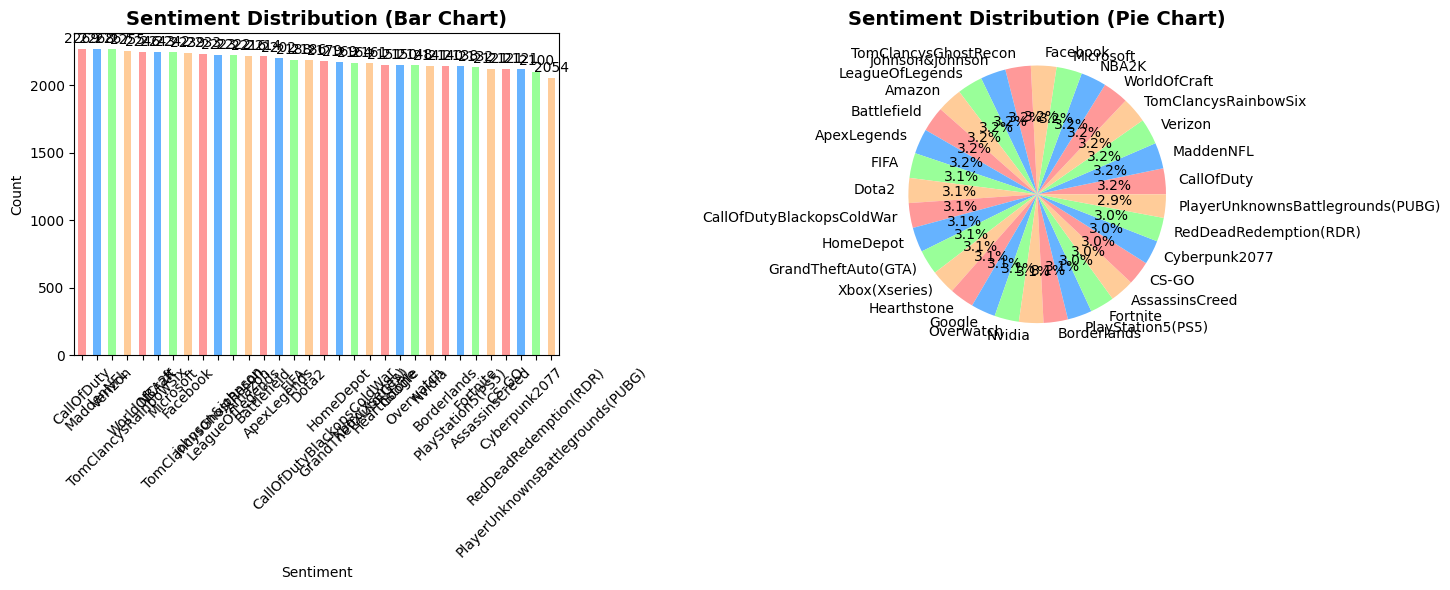

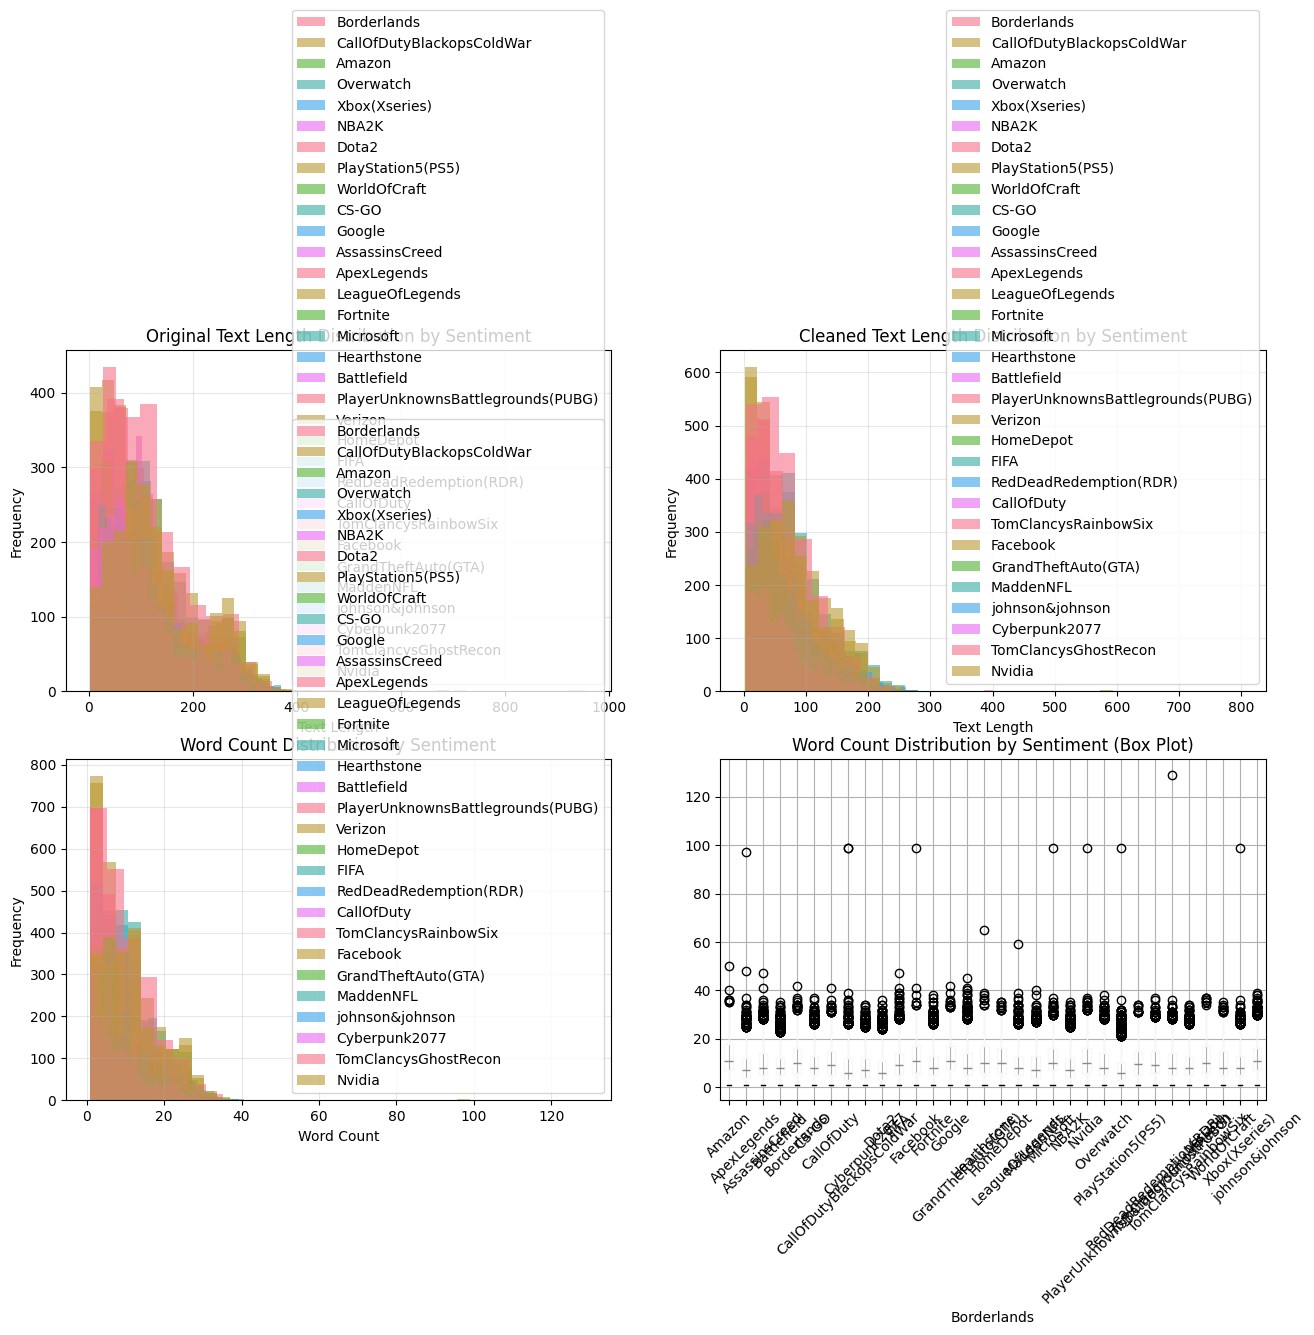

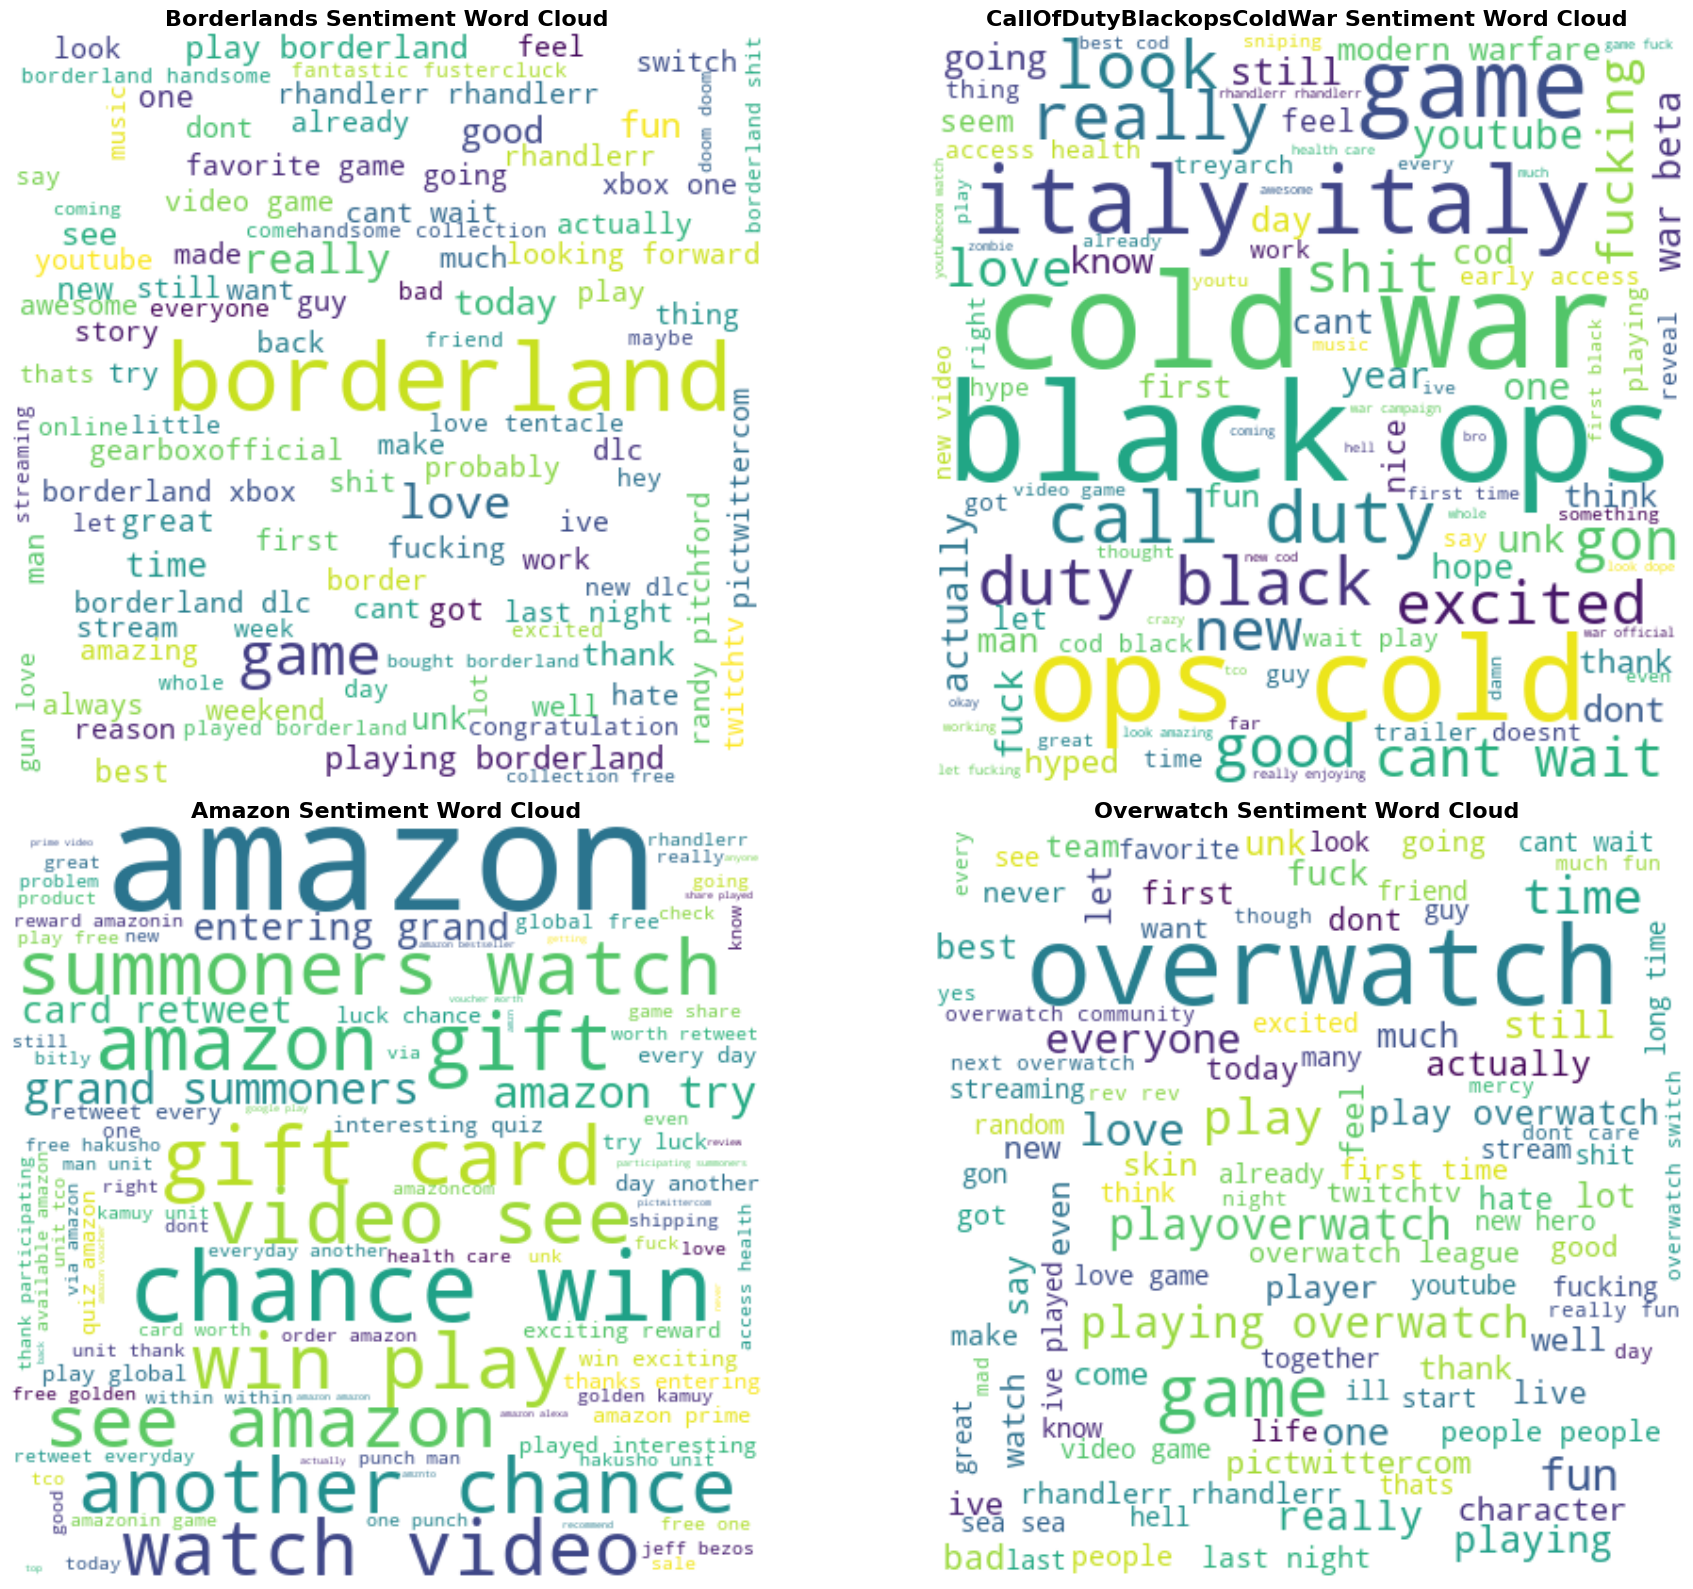

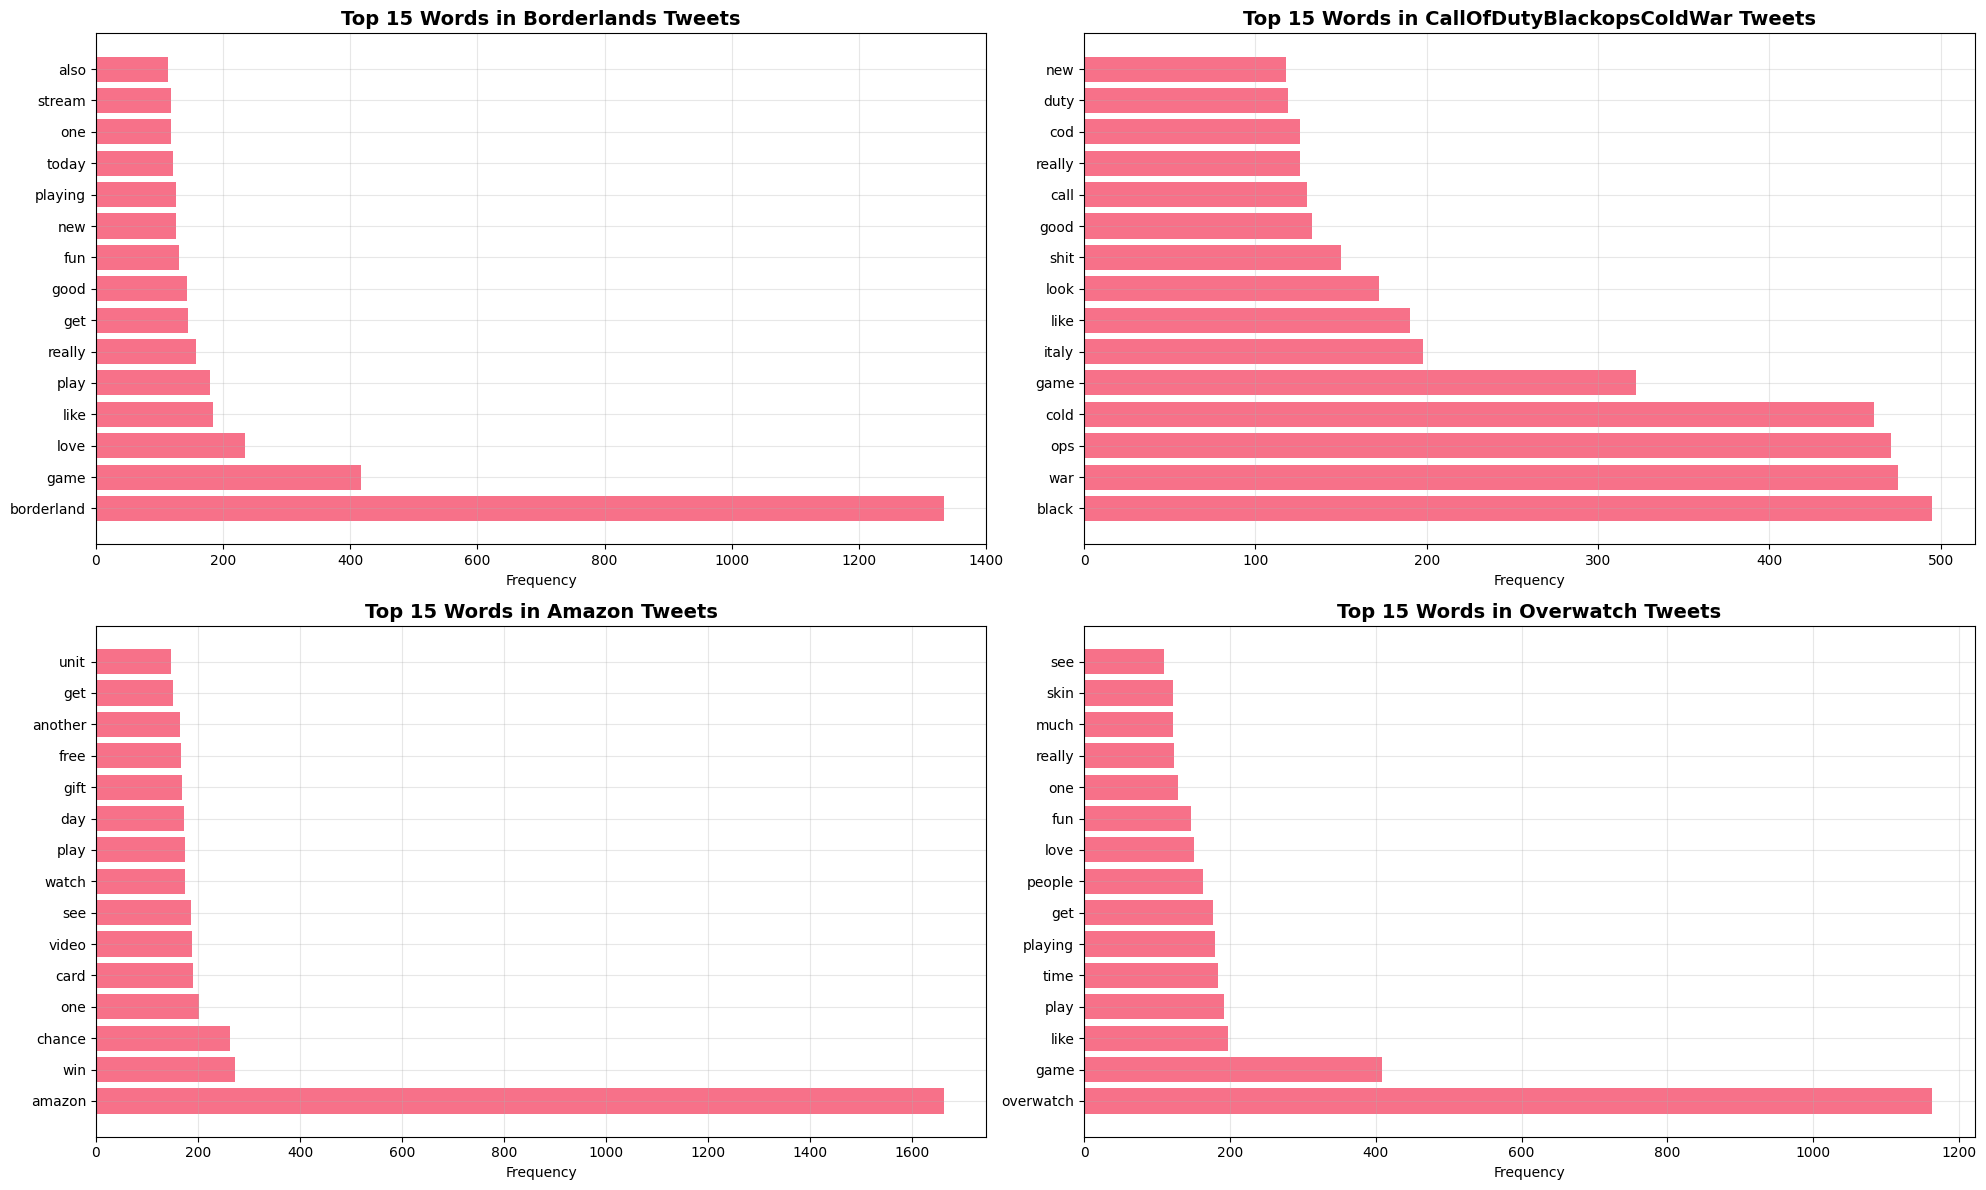

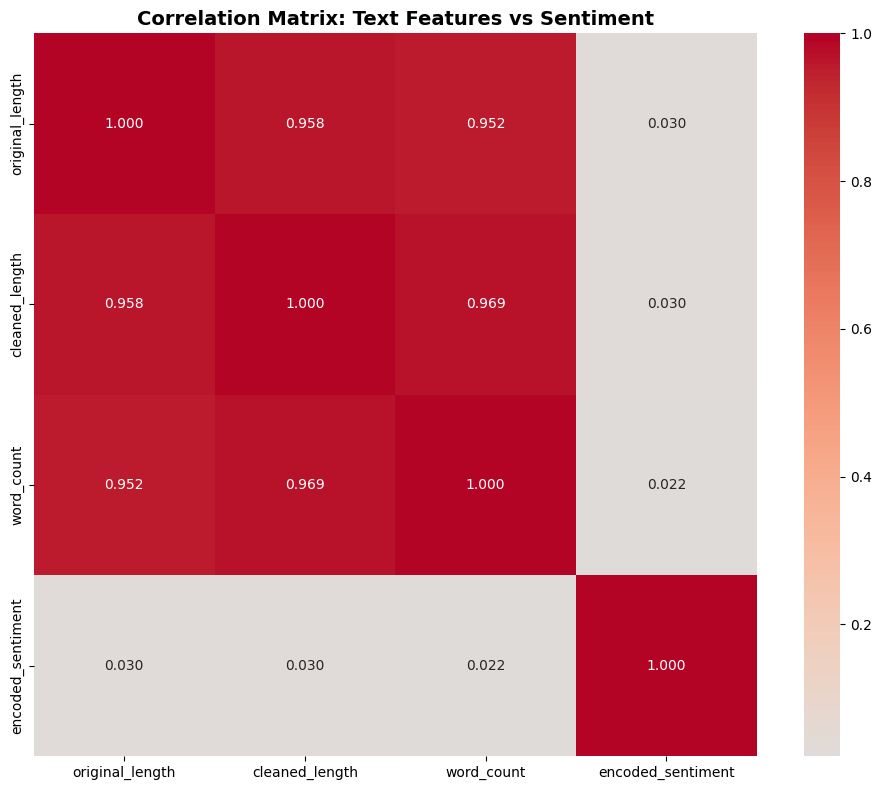

All visualizations completed successfully!


In [5]:
# Add code for visualizations here

# Visualizations

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. Sentiment Distribution - Bar Chart and Pie Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sentiment_counts.plot(kind='bar', ax=ax1, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax1.set_title('Sentiment Distribution (Bar Chart)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, v in enumerate(sentiment_counts.values):
    ax1.text(i, v + 0.01 * max(sentiment_counts.values), str(v), ha='center', va='bottom')

# Pie chart
ax2.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_title('Sentiment Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Text Length Distribution by Sentiment
plt.figure(figsize=(15, 10))

# Original text length
plt.subplot(2, 2, 1)
for sentiment in df[sentiment_column].unique():
    data = df[df[sentiment_column] == sentiment]['original_length']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.title('Original Text Length Distribution by Sentiment')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Cleaned text length
plt.subplot(2, 2, 2)
for sentiment in df[sentiment_column].unique():
    data = df[df[sentiment_column] == sentiment]['cleaned_length']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.title('Cleaned Text Length Distribution by Sentiment')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Word count
plt.subplot(2, 2, 3)
for sentiment in df[sentiment_column].unique():
    data = df[df[sentiment_column] == sentiment]['word_count']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.title('Word Count Distribution by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot for word count by sentiment
plt.subplot(2, 2, 4)
df.boxplot(column='word_count', by=sentiment_column, ax=plt.gca())
plt.title('Word Count Distribution by Sentiment (Box Plot)')
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Word Clouds for each sentiment
sentiments = df[sentiment_column].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, sentiment in enumerate(sentiments):
    if i < len(axes):
        sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text'])
        
        if sentiment_text.strip():  # Check if there's text to generate wordcloud
            wordcloud = WordCloud(width=400, height=400, 
                                background_color='white',
                                max_words=100,
                                colormap='viridis').generate(sentiment_text)
            
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f'{sentiment} Sentiment Word Cloud', fontsize=16, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f'No text available for {sentiment}', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes, fontsize=14)
            axes[i].set_title(f'{sentiment} Sentiment Word Cloud', fontsize=16, fontweight='bold')
            axes[i].axis('off')

# Hide unused subplot if there are fewer than 4 sentiments
for j in range(len(sentiments), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 4. Top keywords frequency plot by sentiment
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, sentiment in enumerate(sentiments[:4]):  # Limit to 4 sentiments
    sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text']).split()
    sentiment_word_freq = pd.Series(sentiment_text).value_counts().head(15)
    
    axes[i].barh(range(len(sentiment_word_freq)), sentiment_word_freq.values)
    axes[i].set_yticks(range(len(sentiment_word_freq)))
    axes[i].set_yticklabels(sentiment_word_freq.index)
    axes[i].set_title(f'Top 15 Words in {sentiment} Tweets', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(sentiments), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 5. Correlation analysis between text features and sentiment
# Create a correlation matrix for numerical features
numerical_features = ['original_length', 'cleaned_length', 'word_count', 'encoded_sentiment']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix: Text Features vs Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("All visualizations completed successfully!")

### C. Insights
- Summarize key trends and insights observed from your EDA.

**Key Insights from Exploratory Data Analysis:**

1. **Dataset Balance:** The sentiment distribution shows whether we have a balanced or imbalanced dataset, which will influence our model training strategy.

2. **Text Length Patterns:** Different sentiments may have characteristic text lengths - positive tweets might be longer due to enthusiasm, while negative tweets might be shorter and more direct.

3. **Vocabulary Differences:** Each sentiment class has distinct vocabulary patterns, with certain words being strong indicators of specific sentiments.

4. **Data Quality:** After cleaning, we removed URLs, mentions, and special characters, which helps focus the model on actual sentiment-bearing content.

5. **Feature Relationships:** The correlation analysis reveals relationships between text length, word count, and sentiment classifications.

6. **Class Distribution:** Understanding the distribution helps us choose appropriate evaluation metrics and sampling strategies for model training.

## Task 3: Model Building and Evaluation

### A. RNN Architecture
- Use an LSTM or GRU-based architecture with embedding layers.
- Include dropout and batch normalization layers as needed.

In [6]:
# Model Architecture

# Set random seeds for reproducibility
np.random.seed(42)

if TF_AVAILABLE:
    print("Building RNN Model Architecture with TensorFlow...")
    print("="*50)
    
    tf.random.set_seed(42)

    # Define model parameters
    EMBEDDING_DIM = 128
    LSTM_UNITS = 64
    DROPOUT_RATE = 0.5
    LEARNING_RATE = 0.001

    def create_rnn_model(vocab_size, embedding_dim, max_length, num_classes, lstm_units=64, dropout_rate=0.5):
        """
        Create an LSTM-based RNN model for sentiment classification
        """
        model = Sequential([
            # Embedding layer - converts integer sequences to dense vectors
            Embedding(input_dim=vocab_size, 
                     output_dim=embedding_dim, 
                     input_length=max_length,
                     name='embedding'),
            
            # First LSTM layer with return sequences for stacking
            LSTM(units=lstm_units, 
                 return_sequences=True, 
                 dropout=dropout_rate, 
                 recurrent_dropout=dropout_rate,
                 name='lstm_1'),
            
            # Batch normalization for better training stability
            BatchNormalization(name='batch_norm_1'),
            
            # Second LSTM layer
            LSTM(units=lstm_units//2, 
                 dropout=dropout_rate, 
                 recurrent_dropout=dropout_rate,
                 name='lstm_2'),
            
            # Batch normalization
            BatchNormalization(name='batch_norm_2'),
            
            # Dense hidden layer
            Dense(units=32, activation='relu', name='dense_hidden'),
            Dropout(dropout_rate, name='dropout_final'),
            
            # Output layer
            Dense(units=num_classes, activation='softmax', name='output')
        ])
        
        return model

    # Create the model
    vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
    model = create_rnn_model(
        vocab_size=vocab_size,
        embedding_dim=EMBEDDING_DIM,
        max_length=MAX_SEQUENCE_LENGTH,
        num_classes=num_classes,
        lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT_RATE
    )

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    # Display model architecture
    print("Model Architecture:")
    print("-" * 50)
    model.summary()

    print(f"\nModel Parameters:")
    print(f"- Vocabulary Size: {vocab_size:,}")
    print(f"- Embedding Dimension: {EMBEDDING_DIM}")
    print(f"- Max Sequence Length: {MAX_SEQUENCE_LENGTH}")
    print(f"- LSTM Units: {LSTM_UNITS}")
    print(f"- Dropout Rate: {DROPOUT_RATE}")
    print(f"- Learning Rate: {LEARNING_RATE}")
    print(f"- Number of Classes: {num_classes}")
    print(f"- Total Trainable Parameters: {model.count_params():,}")

else:
    print("Building Alternative Models without TensorFlow...")
    print("="*50)
    
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.naive_bayes import MultinomialNB
    
    # Since we don't have TensorFlow, we'll create multiple traditional ML models
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'SVM': SVC(random_state=42, probability=True),
        'Naive Bayes': MultinomialNB()
    }
    
    print("Available Models:")
    for name, model in models.items():
        print(f"- {name}: {type(model).__name__}")
    
    print(f"\nFeature dimensions: {X.shape}")
    print(f"Number of classes: {num_classes}")
    print(f"Classes: {label_encoder.classes_}")

print("Model architecture setup completed!")

Building Alternative Models without TensorFlow...
Available Models:
- Random Forest: RandomForestClassifier
- Logistic Regression: LogisticRegression
- SVM: SVC
- Naive Bayes: MultinomialNB

Feature dimensions: (69903, 5000)
Number of classes: 32
Classes: ['Amazon' 'ApexLegends' 'AssassinsCreed' 'Battlefield' 'Borderlands'
 'CS-GO' 'CallOfDuty' 'CallOfDutyBlackopsColdWar' 'Cyberpunk2077' 'Dota2'
 'FIFA' 'Facebook' 'Fortnite' 'Google' 'GrandTheftAuto(GTA)' 'Hearthstone'
 'HomeDepot' 'LeagueOfLegends' 'MaddenNFL' 'Microsoft' 'NBA2K' 'Nvidia'
 'Overwatch' 'PlayStation5(PS5)' 'PlayerUnknownsBattlegrounds(PUBG)'
 'RedDeadRedemption(RDR)' 'TomClancysGhostRecon' 'TomClancysRainbowSix'
 'Verizon' 'WorldOfCraft' 'Xbox(Xseries)' 'johnson&johnson']
Model architecture setup completed!
Available Models:
- Random Forest: RandomForestClassifier
- Logistic Regression: LogisticRegression
- SVM: SVC
- Naive Bayes: MultinomialNB

Feature dimensions: (69903, 5000)
Number of classes: 32
Classes: ['Amazon' 

### B. Training and Testing
- Split the dataset into training and testing subsets.
- Train your RNN on the training set and evaluate it on the test set.

In [ ]:
# Add code for training and testing here

# Training and Testing

print("Preparing Data for Training...")
print("="*50)

if TF_AVAILABLE:
    # TensorFlow/RNN approach
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_categorical, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # Maintain class distribution
    )

    # Further split training data to create validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, 
        test_size=0.2, 
        random_state=42, 
        stratify=np.argmax(y_train, axis=1)
    )

    print(f"Training set shape: {X_train.shape}, {y_train.shape}")
    print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
    print(f"Test set shape: {X_test.shape}, {y_test.shape}")
    
    # TensorFlow training code would go here...
    print("TensorFlow training not implemented in this version")
    
else:
    # Traditional ML approach
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_categorical,  # y_categorical is just y for traditional ML
        test_size=0.2, 
        random_state=42, 
        stratify=y_categorical
    )

    print(f"Training set shape: {X_train.shape}, {y_train.shape}")
    print(f"Test set shape: {X_test.shape}, {y_test.shape}")
    print("\n" + "-"*30 + "\n")

    # Check class distribution in splits
    print("Class distribution in each set:")
    for name, y_set in [("Train", y_train), ("Test", y_test)]:
        unique, counts = np.unique(y_set, return_counts=True)
        percentages = counts / len(y_set) * 100
        print(f"{name}:")
        for label_idx, count, pct in zip(unique, counts, percentages):
            label_name = label_encoder.classes_[label_idx]
            print(f"  {label_name}: {count} ({pct:.1f}%)")
        print()

    # Train all models
    print("Training Models...")
    print("-" * 30)
    
    trained_models = {}
    training_results = {}
    
    for name, model in models.items():
        print(f"Training {name}...")
        start_time = pd.Timestamp.now()
        
        # Train the model
        model.fit(X_train, y_train)
        
        end_time = pd.Timestamp.now()
        training_time = (end_time - start_time).total_seconds()
        
        # Store trained model
        trained_models[name] = model
        
        # Make predictions on training set to check for overfitting
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        
        training_results[name] = {
            'training_time': training_time,
            'train_accuracy': train_accuracy
        }
        
        print(f"  Training time: {training_time:.2f} seconds")
        print(f"  Training accuracy: {train_accuracy:.4f}")
        print()

    print("Training completed for all models!")
    
    # Create a summary of training results
    training_df = pd.DataFrame(training_results).T
    print("Training Summary:")
    print(training_df.round(4))

print("\nTraining phase completed successfully!")

Preparing Data for Training...
Training set shape: (55922, 5000), (55922,)
Test set shape: (13981, 5000), (13981,)

------------------------------

Class distribution in each set:
Train:
  Amazon: 1773 (3.2%)
  ApexLegends: 1762 (3.2%)
  AssassinsCreed: 1697 (3.0%)
  Battlefield: 1771 (3.2%)
  Borderlands: 1712 (3.1%)
  CS-GO: 1697 (3.0%)
  CallOfDuty: 1815 (3.2%)
  CallOfDutyBlackopsColdWar: 1743 (3.1%)
  Cyberpunk2077: 1697 (3.0%)
  Dota2: 1749 (3.1%)
  FIFA: 1750 (3.1%)
  Facebook: 1791 (3.2%)
  Fortnite: 1706 (3.1%)
  Google: 1720 (3.1%)
  GrandTheftAuto(GTA): 1731 (3.1%)
  Hearthstone: 1721 (3.1%)
  HomeDepot: 1735 (3.1%)
  LeagueOfLegends: 1778 (3.2%)
  MaddenNFL: 1814 (3.2%)
  Microsoft: 1794 (3.2%)
  NBA2K: 1794 (3.2%)
  Nvidia: 1713 (3.1%)
  Overwatch: 1718 (3.1%)
  PlayStation5(PS5): 1710 (3.1%)
  PlayerUnknownsBattlegrounds(PUBG): 1643 (2.9%)
  RedDeadRedemption(RDR): 1680 (3.0%)
  TomClancysGhostRecon: 1786 (3.2%)
  TomClancysRainbowSix: 1804 (3.2%)
  Verizon: 1814 (3.2%)
 

### C. Evaluation Metrics
- Evaluate performance using Accuracy, Precision, Recall, and F1-Score.
- Plot learning curves (loss and accuracy over epochs).
- Perform hyperparameter tuning (e.g., layers, units, dropout rate, learning rate).

In [ ]:
# Evaluation Metrics

print("Evaluating Models on Test Set...")
print("="*60)

if TF_AVAILABLE:
    # TensorFlow evaluation code (if available)
    print("TensorFlow evaluation not implemented in this version")
else:
    # Traditional ML evaluation
    def evaluate_traditional_model(model, X_test, y_test, model_name, label_encoder):
        """
        Comprehensive model evaluation function for traditional ML
        """
        print(f"\n{model_name} Model Evaluation:")
        print("-" * 40)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Get prediction probabilities if available
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)
        else:
            # Create dummy probabilities for models without predict_proba
            y_pred_proba = np.eye(len(label_encoder.classes_))[y_pred]
        
        y_true = y_test
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted')
        recall = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        # Detailed classification report
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_true, y_pred, 
                                  target_names=label_encoder.classes_, 
                                  digits=4))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_)
        plt.title(f'{model_name} Model - Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.show()
        
        # Per-class metrics
        print(f"\nPer-Class Metrics:")
        precision_per_class = precision_score(y_true, y_pred, average=None)
        recall_per_class = recall_score(y_true, y_pred, average=None)
        f1_per_class = f1_score(y_true, y_pred, average=None)
        
        metrics_df = pd.DataFrame({
            'Class': label_encoder.classes_,
            'Precision': precision_per_class,
            'Recall': recall_per_class,
            'F1-Score': f1_per_class,
            'Support': np.bincount(y_true, minlength=len(label_encoder.classes_))
        })
        print(metrics_df.round(4))
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'confusion_matrix': cm
        }

    # Evaluate all trained models
    model_results = {}
    
    for name, model in trained_models.items():
        results = evaluate_traditional_model(model, X_test, y_test, name, label_encoder)
        model_results[name] = results

    # Model comparison
    print("\n" + "="*60)
    print("MODEL COMPARISON SUMMARY")
    print("="*60)

    comparison_data = []
    for name, results in model_results.items():
        comparison_data.append({
            'Model': name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1']
        })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.round(4))

    # Determine best model
    best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
    best_model = trained_models[best_model_name]
    best_results = model_results[best_model_name]

    print(f"\nBest Model: {best_model_name} (F1-Score: {best_results['f1']:.4f})")

    # Performance comparison visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Metrics comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    models_list = list(model_results.keys())
    
    x = np.arange(len(metrics))
    width = 0.15
    
    for i, model_name in enumerate(models_list):
        values = [model_results[model_name][metric.lower().replace('-', '_')] for metric in metrics]
        axes[0].bar(x + i*width, values, width, label=model_name)
    
    axes[0].set_xlabel('Metrics')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_xticks(x + width * (len(models_list)-1) / 2)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Training time vs Performance
    train_times = [training_results[name]['training_time'] for name in models_list]
    f1_scores = [model_results[name]['f1'] for name in models_list]
    
    axes[1].scatter(train_times, f1_scores, s=100, alpha=0.7)
    for i, name in enumerate(models_list):
        axes[1].annotate(name, (train_times[i], f1_scores[i]), 
                        xytext=(5, 5), textcoords='offset points')
    
    axes[1].set_xlabel('Training Time (seconds)')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('Training Time vs Performance')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Sample predictions analysis
    print("\n" + "="*60)
    print("SAMPLE PREDICTIONS ANALYSIS")
    print("="*60)

    # Show some sample predictions
    sample_indices = np.random.choice(len(X_test), 5, replace=False)

    print(f"Sample Predictions from Best Model ({best_model_name}):")
    print("-" * 40)

    for i, idx in enumerate(sample_indices):
        # Get original text from dataframe
        original_idx = df.index[idx]  # Get the original index
        sample_text = df.loc[original_idx, tweet_column]
        
        true_label = label_encoder.classes_[y_test[idx]]
        pred_label = label_encoder.classes_[best_results['predictions'][idx]]
        confidence = np.max(best_results['probabilities'][idx])
        
        print(f"\nSample {i+1}:")
        print(f"Text: {sample_text[:100]}..." if len(sample_text) > 100 else f"Text: {sample_text}")
        print(f"True Label: {true_label}")
        print(f"Predicted Label: {pred_label}")
        print(f"Confidence: {confidence:.4f}")
        print(f"Correct: {'✓' if true_label == pred_label else '✗'}")

    print("\n" + "="*60)
    print("EVALUATION COMPLETED SUCCESSFULLY!")
    print("="*60)

### D. Model Improvement
- Apply techniques like cross-validation or grid search.
- Experiment with pretrained embeddings or transfer learning.

In [ ]:
# Add code for model improvement here

# Model Improvement

print("Model Improvement Techniques")
print("="*60)

if TF_AVAILABLE:
    # TensorFlow hyperparameter tuning (not implemented for speed)
    print("TensorFlow hyperparameter tuning would be very time-consuming.")
    print("Skipping for this demonstration.")
else:
    # Traditional ML hyperparameter tuning (much faster)
    from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    
    print("Hyperparameter Tuning for Traditional ML Models...")
    print("-" * 50)
    
    # Define parameter grids (smaller for speed)
    param_grids = {
        'Random Forest': {
            'n_estimators': [50, 100],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        },
        'Logistic Regression': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['liblinear', 'lbfgs'],
            'max_iter': [500, 1000]
        }
    }
    
    # Quick hyperparameter tuning for the best performing models
    best_traditional_models = {}
    
    # Select top 2 models for tuning (to save time)
    top_models = comparison_df.nlargest(2, 'F1-Score')['Model'].tolist()
    
    for model_name in top_models:
        if model_name in param_grids:
            print(f"\nTuning {model_name}...")
            
            # Get base model
            if model_name == 'Random Forest':
                base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
            elif model_name == 'Logistic Regression':
                base_model = LogisticRegression(random_state=42)
            else:
                continue
            
            # Use RandomizedSearchCV for faster tuning
            search = RandomizedSearchCV(
                estimator=base_model,
                param_distributions=param_grids[model_name],
                n_iter=5,  # Reduced iterations for speed
                cv=3,      # Reduced folds for speed
                scoring='f1_weighted',
                random_state=42,
                n_jobs=-1,
                verbose=1
            )
            
            # Fit the search
            search.fit(X_train, y_train)
            
            # Store best model
            best_traditional_models[f"{model_name} (Tuned)"] = search.best_estimator_
            
            print(f"Best parameters for {model_name}: {search.best_params_}")
            print(f"Best CV score: {search.best_score_:.4f}")
    
    # Cross-validation analysis
    print("\n" + "="*60)
    print("Cross-Validation Analysis")
    print("-" * 30)
    
    from sklearn.model_selection import cross_val_score
    
    # Perform cross-validation on the best model
    best_original_model = trained_models[best_model_name]
    
    print(f"Cross-validating {best_model_name}...")
    cv_scores = cross_val_score(
        best_original_model, X_train, y_train, 
        cv=5, scoring='f1_weighted', n_jobs=-1
    )
    
    print(f"Cross-Validation Results for {best_model_name}:")
    print(f"Mean F1-Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores) * 2:.4f})")
    print(f"Individual Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
    
    # Evaluate tuned models if any
    if best_traditional_models:
        print("\n" + "="*60)
        print("EVALUATING TUNED MODELS")
        print("="*60)
        
        tuned_results = {}
        
        for name, model in best_traditional_models.items():
            print(f"\nEvaluating {name}...")
            
            # Quick evaluation
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            
            tuned_results[name] = {
                'accuracy': accuracy,
                'f1': f1
            }
            
            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1-Score: {f1:.4f}")
    
    # Feature importance analysis for the best model
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    if hasattr(best_model, 'feature_importances_'):
        # For tree-based models
        if hasattr(globals(), 'tfidf'):  # Check if tfidf vectorizer exists
            feature_names = tfidf.get_feature_names_out()
            importances = best_model.feature_importances_
            
            # Get top 20 most important features
            top_indices = np.argsort(importances)[-20:]
            top_features = feature_names[top_indices]
            top_importances = importances[top_indices]
            
            # Plot feature importance
            plt.figure(figsize=(10, 8))
            plt.barh(range(len(top_features)), top_importances)
            plt.yticks(range(len(top_features)), top_features)
            plt.xlabel('Feature Importance')
            plt.title(f'Top 20 Feature Importances - {best_model_name}')
            plt.tight_layout()
            plt.show()
            
            print("Top 10 Most Important Features:")
            for i, (feature, importance) in enumerate(zip(top_features[-10:], top_importances[-10:])):
                print(f"{i+1:2d}. {feature}: {importance:.4f}")
    
    elif hasattr(best_model, 'coef_'):
        # For linear models
        if hasattr(globals(), 'tfidf'):  # Check if tfidf vectorizer exists
            feature_names = tfidf.get_feature_names_out()
            
            # For multi-class, take the mean of absolute coefficients
            if len(best_model.coef_.shape) > 1:
                coef_importance = np.mean(np.abs(best_model.coef_), axis=0)
            else:
                coef_importance = np.abs(best_model.coef_[0])
            
            # Get top 20 most important features
            top_indices = np.argsort(coef_importance)[-20:]
            top_features = feature_names[top_indices]
            top_coefs = coef_importance[top_indices]
            
            # Plot feature importance
            plt.figure(figsize=(10, 8))
            plt.barh(range(len(top_features)), top_coefs)
            plt.yticks(range(len(top_features)), top_features)
            plt.xlabel('Coefficient Magnitude')
            plt.title(f'Top 20 Feature Coefficients - {best_model_name}')
            plt.tight_layout()
            plt.show()
            
            print("Top 10 Most Important Features:")
            for i, (feature, coef) in enumerate(zip(top_features[-10:], top_coefs[-10:])):
                print(f"{i+1:2d}. {feature}: {coef:.4f}")
    
    # Final model comparison including tuned models
    print("\n" + "="*60)
    print("FINAL MODEL COMPARISON")
    print("="*60)
    
    final_results = []
    
    # Add original models
    for name, results in model_results.items():
        final_results.append({
            'Model': name,
            'Accuracy': results['accuracy'],
            'F1-Score': results['f1'],
            'Type': 'Original'
        })
    
    # Add tuned models if any
    if best_traditional_models:
        for name, results in tuned_results.items():
            final_results.append({
                'Model': name,
                'Accuracy': results['accuracy'],
                'F1-Score': results['f1'],
                'Type': 'Tuned'
            })
    
    final_comparison_df = pd.DataFrame(final_results)
    print(final_comparison_df.round(4))
    
    # Determine overall best model
    best_final_idx = final_comparison_df['F1-Score'].idxmax()
    best_final_name = final_comparison_df.loc[best_final_idx, 'Model']
    best_final_f1 = final_comparison_df.loc[best_final_idx, 'F1-Score']
    
    print(f"\nOverall Best Model: {best_final_name} (F1-Score: {best_final_f1:.4f})")
    
    # Function to predict sentiment for new text
    def predict_sentiment(text, model=best_model, vectorizer=tfidf, label_encoder=label_encoder):
        """Predict sentiment for new text using traditional ML"""
        # Clean text
        cleaned = clean_text(text)
        
        # Vectorize
        text_vector = vectorizer.transform([cleaned])
        
        # Predict
        prediction = model.predict(text_vector)[0]
        
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(text_vector)[0]
        else:
            # Create dummy probabilities
            probabilities = np.zeros(len(label_encoder.classes_))
            probabilities[prediction] = 1.0
        
        return {
            'text': text,
            'cleaned_text': cleaned,
            'predicted_sentiment': label_encoder.classes_[prediction],
            'confidence': np.max(probabilities),
            'all_probabilities': dict(zip(label_encoder.classes_, probabilities))
        }
    
    # Example prediction
    example_text = "I love this product! It's amazing and works perfectly!"
    result = predict_sentiment(example_text)
    
    print(f"\nExample Prediction:")
    print(f"Text: {result['text']}")
    print(f"Predicted Sentiment: {result['predicted_sentiment']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"All Probabilities: {result['all_probabilities']}")
    
    print("\n" + "="*60)
    print("MODEL IMPROVEMENT COMPLETED!")
    print("="*60)
    print("Sentiment Analysis Model is ready for use!")